In [9]:
%pip install numpy
%pip install missingno matplotlib

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


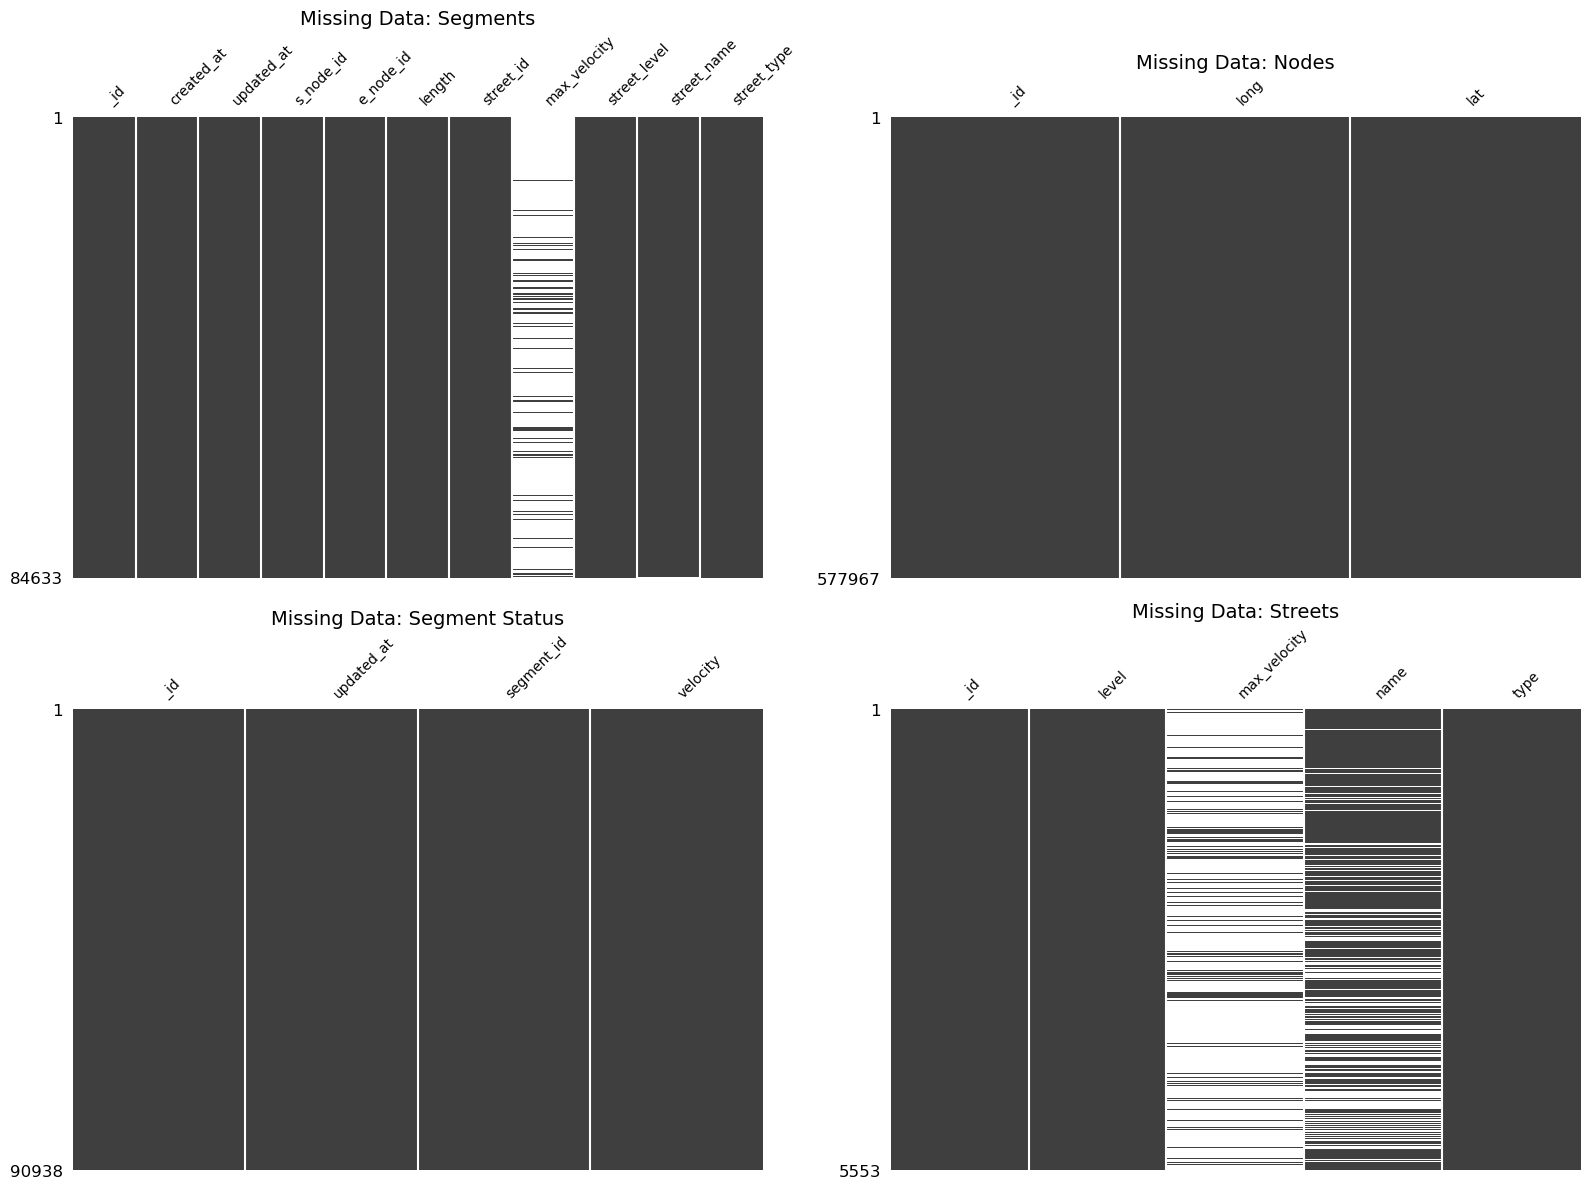

In [10]:
import pandas as pd
import missingno as msno
import matplotlib.pyplot as plt

data_seg=pd.read_csv("./segments.csv")
data_node=pd.read_csv("./nodes.csv")
data_seg_stat=pd.read_csv("./segment_status.csv")
data_streets=pd.read_csv("./streets.csv")

# Check all dataset to find any nullable
# show missing values of data_streets
datasets = [
    (data_seg, "Segments"),
    (data_node, "Nodes"),
    (data_seg_stat, "Segment Status"),
    (data_streets, "Streets")
]
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(16, 12))
axes_flat = axes.flatten()

for i, (df, name) in enumerate(datasets):
    msno.matrix(df, ax=axes_flat[i], sparkline=False, fontsize=10)
    axes_flat[i].set_title(f"Missing Data: {name}", fontsize=14)

plt.tight_layout()
plt.show()


In [11]:
# Check value from not nullable records
filtered_streets = data_streets.dropna(subset=['max_velocity']).drop_duplicates(subset=['level'], keep='first')
print("Danh sách các 'level' duy nhất kèm max_velocity:")
print(filtered_streets[['level', 'max_velocity']])

Danh sách các 'level' duy nhất kèm max_velocity:
     level  max_velocity
0        1          80.0
6        3          40.0
42       4          40.0
319      2          60.0


In [12]:
# re-fill missing data
speed_map = {
    1: 80.0,
    2: 60.0,
    3: 40.0,
    4: 40.0
}

print("Filling data")

# 1. Sử dụng .loc để điền khuyết cho data_streets một cách an toàn
data_streets.loc[:, 'max_velocity'] = data_streets['max_velocity'].fillna(data_streets['level'].map(speed_map))

# 2. Tạo bảng tra cứu tốc độ từ data_streets (sử dụng đúng cột '_id' như code của bạn)
street_speed_lookup = data_streets.set_index('_id')['max_velocity']

# 3. Sử dụng .loc để điền khuyết cho data_seg nhằm triệt tiêu hoàn toàn SettingWithCopyWarning
data_seg.loc[:, 'max_velocity'] = data_seg['max_velocity'].fillna(data_seg['street_id'].map(street_speed_lookup))

print("Filled successfully")

# Lưu cả 2 file sau khi xử lý khuyết dòng
data_streets.to_csv("../refined/streets.csv", index=False)
data_seg.to_csv("../refined/segments.csv", index=False)

Filling data
Filled successfully
